In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 -4*x + 5

In [3]:
f(3.0)

20.0

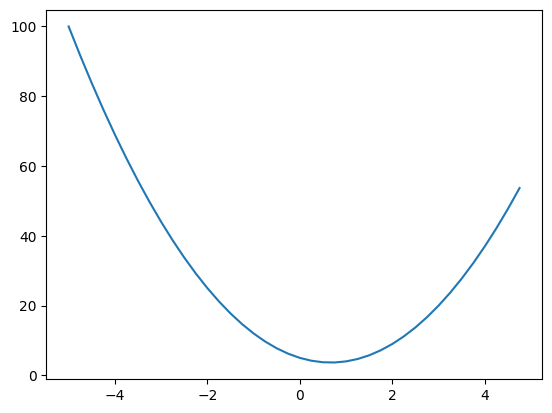

In [4]:
xs = np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)

In [5]:
# The derivative of f(x) is 6*x - 4, so at x = 2/3, the derivative is 0.
h = 0.000001
x = 2/3
(f(x+h) - f(x)) / h

2.999378523327323e-06

In [6]:
# more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
# Now let's see how the value of d changes when we change a by a small amount h.
h=0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c
print('d1:', d1)
print('d2:', d2)
print('slope:', (d2-d1)/h)

d1: 4.0
d2: 3.999699999999999
slope: -3.000000000010772


In [8]:
# Now let's see how the value of d changes when we change b by a small amount h.
h=0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c
print('d1:', d1)
print('d2:', d2)
print('slope:', (d2-d1)/h)

d1: 4.0
d2: 4.0001
slope: 0.9999999999976694


In [9]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None  
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other): # self / other = self * other**-1
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad # because the derivative of exp(x) is exp(x) and out.grad is the gradient of the output with respect to the final output, so we multiply them together to get the gradient of the input with respect to the final output.
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [10]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [11]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [12]:
!brew install graphviz

⠋ JSON API formula.jws.json                          Downloading  32.8MB/-------
⠋ JSON API cask.jws.json                             Downloading  16.9MB/-------Warning: formula.jws.json: update failed, falling back to cached version.
⠋ JSON API formula.jws.json                          Downloading  32.8MB/-------
⠙ JSON API cask.jws.json                             Downloaded   16.9MB/-------✔︎ JSON API formula.jws.json                          Downloaded   32.8MB/ 32.8MB
✔︎ JSON API cask.jws.json                             Downloaded   16.9MB/ 16.9MB
To reinstall 15.0.0, run:
  brew reinstall graphviz


In [13]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

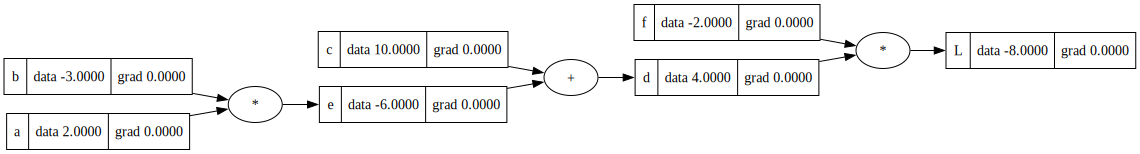

In [14]:
draw_dot(L)

L = d * f  
dL/dd = f

We can derive it by using the definition of derivative:

- (f(x + h) - f(x)) / h
- ((d + h) * f - d * f) / h
- (d * f + h * f - d * f) / h
- h * f / h
- f

Similarly dL/df = d because L = d * f


- **dd/dc = 1.0** and **dd/de = 1.0**
- Why? Because d = c + e, so each input contributes equally to d's value.

**Analytical Derivation:**
Using the definition of derivative:
- (f(x+h) - f(x)) / h
- ((c+h + e) - (c + e)) / h
- (h) / h
- **= 1**

**Applying the Chain Rule:**
To find how L changes with respect to c and e, we use:
- **dz/dx = (dz/dy) × (dy/dx)**

In our case:
- L depends on d (L = d × f)
- d depends on c and e (d = c + e)
- Therefore: **dL/dc = (dL/dd) × (dd/dc)**

**Key Insight — The Addition Node:**
When a value is created by addition (d = c + e), the derivative simply passes through unchanged:
- The '+' operator acts as a "router" — it doesn't amplify or reduce the gradient
- Both inputs contribute equally: each has a derivative of 1 with respect to the output
- So: dd/dc = 1 and dd/de = 1

**Concrete Example:**
- We know dL/dd = -2 (from the multiplication d × f)
- Therefore: dL/dc = (-2) × (1) = **-2**
- And: dL/de = (-2) × (1) = **-2**

Now we want dL / da

We know,

- dL / de = -2.0

- e = a * b

Therefore,
- de/da = b

- dL /da = (dL / de) * (de / da)
- dL /da = -2.0 * b => -2.0 * -3.0 => 6.0

In [15]:
L.grad = 1.0
#refering above dL/df = d and dL/dd = f
f.grad = 4.0
d.grad = -2.0

c.grad = -2.0 #since dL/dc = dL/dd * dd/dc = f * 1 = f
e.grad = -2.0 #similaerly, dL/de = dL/dd * dd/de = f * 1 = f

a.grad = -2.0 * -3.0 #since dL/da = dL/de * de/da = f * -3.0 = -2.0 * -3.0
b.grad = -2.0 * 2.0 #since dL/db = dL/de * de/db = f * 2.0 = -2.0 * 2.0

In [16]:
# Now we have the gradients of L with respect to a, b, c, and f. We can use these gradients to perform gradient descent and update the values of a, b, c, and f to minimize L.
# We can nudge these gradients by step_size to update the values of a, b, c, and f to minimize L, basically make L less negative.
step_size = 0.01
a.data += step_size * a.grad
b.data += step_size * b.grad
c.data += step_size * c.grad
f.data += step_size * f.grad

# After one step of gradient descent, the value of L should be less negative than before. So forward pass again to see the new value of L.
e = a * b
d = e + c
L = d * f
print(L.data)

-7.286496


In [ ]:
# This is a numerical approximation of the derivative of L with respect to d, which should be close to -2.0 -> this is an example of numerical differentiation.
# This is equivalent to the dL/dd = f that we have above, which is the analytical derivative.

def lol():
    h=0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    # a.data += h
    b = Value(-3.0, label='b')
    b.data += h
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h)
lol()

-3.9999999999995595


## Simulating Neuron

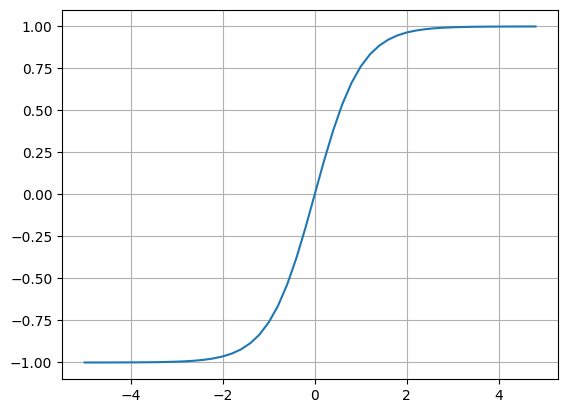

In [18]:
# Plotting tanh activation function

plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [19]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# forward pass x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

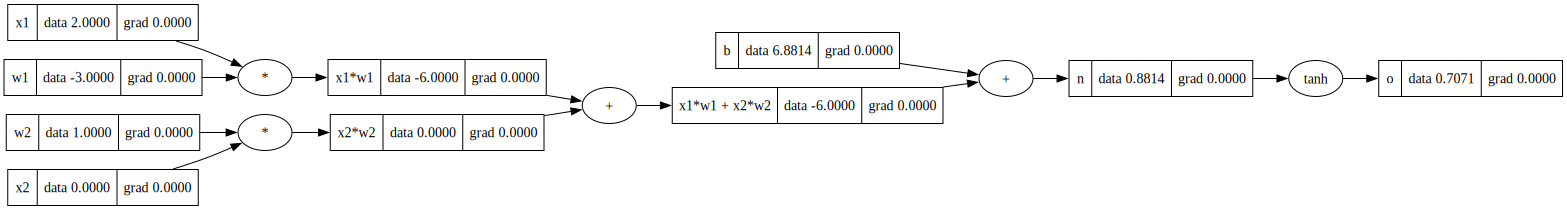

In [20]:
draw_dot(o)

In [21]:
# Now we can perform backpropagation to compute the gradients of o with respect to x1, x2, w1, w2, and b. We can then use these 
# gradients to perform gradient descent and update the values of x1, x2, w1, w2, and b to minimize o.

o.grad = 1.0 # because do/do = 1, we can set the gradient of o to 1.0 to start the backpropagation process.

- o = tanh(n)
- do/dn = 1 - o**2
- 1 - o.data**2 = 0.4999999999999999

 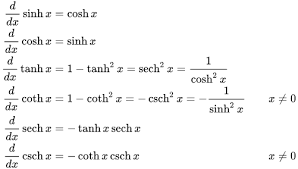


In [22]:
1 - o.data**2

0.4999999999999999

In [23]:
# we are going backwards through the graph, so we can use the chain rule to compute the gradients of o with respect to n, x1w1x2w2, and b.
n.grad =0.5 # since do/dn = 1 - tanh(n)**2

x1w1x2w2.grad = n.grad * 1.0 # since dn/d(x1w1 + x2w2) = 1.0 => do/d(x1w1 + x2w2) = do/dn * dn/d(x1w1 + x2w2) = 0.5 * 1.0 = 0.5
b.grad = n.grad * 1.0 # since dn/db = 1.0 => do/db = do/dn * dn/db = 0.5 * 1.0 = 0.5

# similarly, using chain rule, we can compute the gradients of o with respect to x1w1 and x2w2.
x1w1.grad = 0.5 # since do/d(x1w1) = do/d(x1w1 + x2w2) * d(x1w1 + x2w2)/d(x1w1) = 0.5 * 1.0 = 0.5
x2w2.grad = 0.5 # since do/d(x2w2) = do/d(x1w1 + x2w2) * d(x1w1 + x2w2)/d(x2w2) = 0.5 * 1.0 = 0.5

# similary, using chain rule, we can compute the gradients of o with respect to x1, w1, x2, and w2.
# do/dx2 = do/d(x2w2) * d(x2w2)/dx2 = 0.5 * w2.data = 0.5 * 1.0 = 0.5
x2.grad = 0.5 * w2.data
# do/dw2 = do/d(x2w2) * d(x2w2)/dw2 = 0.5 * x2.data = 0.5 * 0.0 = 0.0 
w2.grad = 0.5 * x2.data
# do/dx1 = do/d(x1w1) * d(x1w1)/dx1 = 0.5 * w1.data = 0.5 * -3.0 = -1.5
x1.grad = 0.5 * w1.data
# do/dw1 = do/d(x1w1) * d(x1w1)/dw1 = 0.5 * x1.data = 0.5 * 2.0 = 1.0
w1.grad = 0.5 * x1.data

### Applying backpropogation through code

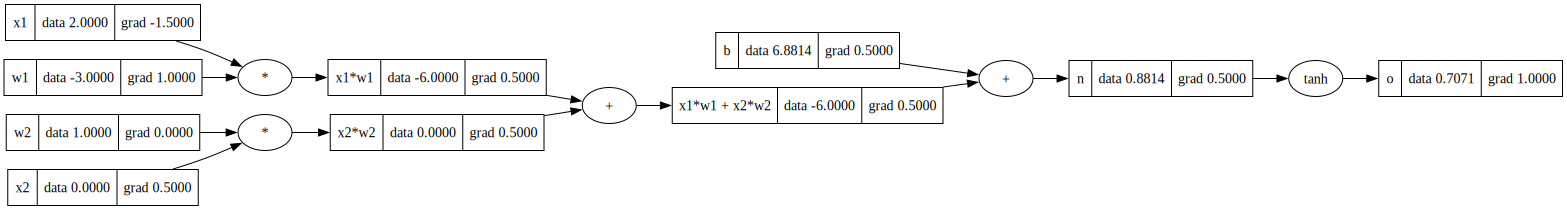

In [24]:
draw_dot(o)

In [25]:
o.grad = 1.0
o._backward() # this will call the _backward function of o, which will compute the gradients of o with respect to n, x1w1x2w2, and b.

In [26]:
n._backward() # this will call the _backward function of n, which will compute the gradients of n with respect to x1w1, x2w2, and b.

b._backward() # this will call the _backward function of b, which will compute the gradients of b with respect to x1w1, x2w2, and b.
x1w1x2w2._backward() # this will call the _backward function of x1w1x2w2, which will compute the gradients of x1w1x2w2 with respect to x1w1 and x2w2.
x1w1._backward() # this will call the _backward function of x1w1, which will compute the gradients of x1w1 with respect to x1 and w1.
x2w2._backward() # this will call the _backward function of x2w2, which will compute the gradients of x2w2 with respect to x2 and w2.
w2._backward() # this will call the _backward function of w2, which will compute the gradients of w2 with respect to x2 and w2.
x2._backward() # this will call the _backward function of x2, which will compute the gradients of x2 with respect to x2 and w2.
w1._backward() # this will call the _backward function of w1, which will compute the gradients of w1 with respect to x1 and w1.
x1._backward() # this will call the _backward function of x1, which will compute the gradients of x1 with respect to x1 and w1.

### Removing multi call to _backword() using topological sort -> basically a single function call would do back propogation

In [27]:
o.backward() # this will call the backward function of o, which will compute the gradients of o with respect to n, x1w1x2w2, b, x1w1, x2w2, x1, w1, x2, and w2 in the correct order.

### More granual implementation of tanh(x)

In [28]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# forward pass x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#---breaking tanh----
e = (2*n).exp()
o = (e -1) / (e + 1); o.label = 'o'
#---------

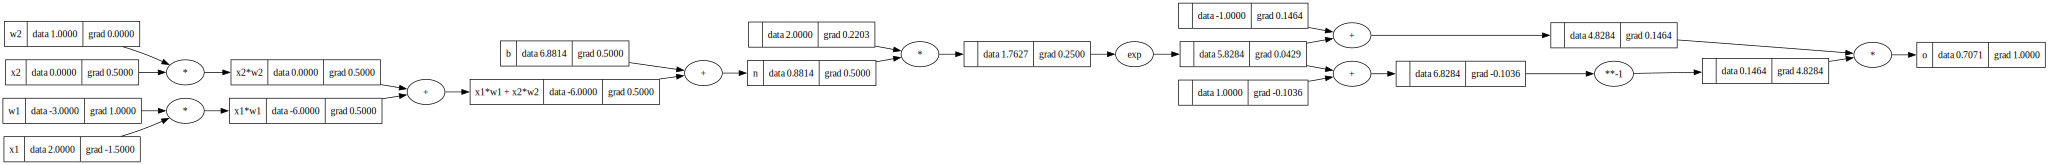

In [29]:
o.backward()
draw_dot(o)

### Doing similar operation in pyTorch

In [30]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [31]:
import torch

In [32]:
x1 = torch.Tensor([2.0]).double()                   ;x1.requires_grad=True
x2 = torch.Tensor([0.0]).double()                   ;x2.requires_grad=True
w1 = torch.Tensor([-3.0]).double()                  ;w1.requires_grad=True
w2 = torch.Tensor([1.0]).double()                   ;w2.requires_grad=True
b = torch.Tensor([6.8813735870195432]).double()     ;b.requires_grad=True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('-------')
print('x2 grad:', x2.grad.item())
print('w2 grad:', w2.grad.item())
print('x1 grad:', x1.grad.item())
print('w1 grad:', w1.grad.item())
print('b grad:', b.grad.item())

0.7071066904050358
-------
x2 grad: 0.5000001283844369
w2 grad: 0.0
x1 grad: -1.5000003851533106
w1 grad: 1.0000002567688737
b grad: 0.5000001283844369


### Multi Layer Perceptron

In [73]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * X + b
        activation = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = activation.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        params=[]
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        params = []
        for layer in self.layers:
            ps = layer.parameters()
            params.extend(ps)
        return params

In [139]:
x = [2.0,3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data=0.3984667926375897)

In [135]:
len(n.parameters())

41

### Simple dataset of binary classifier

In [140]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets for each input above
ypred = [n(x) for x in xs]
ypred

[Value(data=0.3984667926375897),
 Value(data=-0.5814538802475198),
 Value(data=-0.2202663783732169),
 Value(data=0.2610455218625938)]

#### We want out ypred to come as much close as possible to ys which is not currentlt the case, we will calculate the loss using ypred and ys
- ygt = y ground truth
- yout = y output

In [78]:
[(yout - ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(data=3.314870830692813),
 Value(data=0.45177501371883616),
 Value(data=0.04594322755937761),
 Value(data=3.028039507427127)]

### Forward pass

In [ ]:

ypred = [n(x) for x in xs]
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))
loss

Value(data=6.840628579398154)

#### After 1st update to parameters by tiny amount

In [126]:
ypred = [n(x) for x in xs]
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))
loss

Value(data=7.999992347368573)

### Backprop

In [121]:
loss.backward()

In [123]:
n.layers[0].neurons[0].w[0].grad

3.759678265365794

In [122]:
n.layers[0].neurons[0].w[0].data

-1.5986263431658412

### updating parameters by tiny amount

In [124]:
for p in n.parameters():
    p.data += -0.1 * p.grad

In [125]:
n.layers[0].neurons[0].w[0].data

-1.9745941697024205

In [127]:
ypred

[Value(data=-0.9999992816989658),
 Value(data=-0.9999670198804932),
 Value(data=-0.9999907819797687),
 Value(data=-0.9999988048495264)]

### Forward + Backward pass

In [184]:
step_size = 0.05
iters = 1000
for k in range(iters):
    
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0))

    #backprop
    loss.backward()

    #update weights
    for p in n.parameters():
        p.data += -step_size * p.grad

    #zero gradients
    for p in n.parameters():
        p.grad = 0.0

    print(k, loss.data)

0 2.3728610573070626e-05
1 2.372673476322357e-05
2 2.3724859247090836e-05
3 2.372298402460468e-05
4 2.3721109095697786e-05
5 2.371923446030016e-05
6 2.371736011834411e-05
7 2.371548606975908e-05
8 2.371361231447831e-05
9 2.3711738852434313e-05
10 2.3709865683554795e-05
11 2.3707992807774368e-05
12 2.3706120225023004e-05
13 2.3704247935233876e-05
14 2.3702375938337282e-05
15 2.3700504234265066e-05
16 2.3698632822949156e-05
17 2.3696761704319774e-05
18 2.369489087831052e-05
19 2.3693020344852e-05
20 2.3691150103875704e-05
21 2.368928015531358e-05
22 2.3687410499098233e-05
23 2.368554113515863e-05
24 2.3683672063430525e-05
25 2.368180328384293e-05
26 2.3679934796328494e-05
27 2.3678066600819212e-05
28 2.3676198697245626e-05
29 2.3674331085542165e-05
30 2.367246376563839e-05
31 2.367059673746666e-05
32 2.366873000096059e-05
33 2.366686355605025e-05
34 2.366499740266821e-05
35 2.3663131540746178e-05
36 2.3661265970215167e-05
37 2.3659400691011998e-05
38 2.3657535703062538e-05
39 2.365567100

In [185]:
ypred

[Value(data=0.9975566709679683),
 Value(data=-0.9987689952545772),
 Value(data=-0.9977876647396281),
 Value(data=0.9968998585911111)]